# LogiSense — Notebook 04: ML Classification & Regression

## Purpose
This notebook builds and compares machine-learning models for the LogiSense logistics dataset.

**Classification:** predict `late_delivery`  
**Regression:** predict `actual_delivery_days`

### Reliability fixes included
- All required imports are contained in the notebook.
- Both classification and regression use **dense** one-hot encoding, preventing sparse/dense incompatibility with gradient-boosting models.
- No stale `search` variable; hyperparameter tuning consistently uses `random_search`.
- Random Forest tuning is intentionally lightweight: **8 candidates × 3 folds = 24 fits**, instead of 100 fits.
- Leakage-prone outcome columns are excluded from predictors.
- The notebook can be run from top to bottom after a kernel restart.
- Trained models and metadata are saved into the project's `models/` directory.

> **Run this notebook from the first cell. Do not resume from an old execution state.**


In [1]:
# ============================================================
# 1. Imports and configuration
# ============================================================

import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    KFold,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Project structure:
# LogiSense/
# ├── data/raw/*.csv
# ├── notebooks/04_...
# └── models/

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", RAW_DIR)
print("Model directory:", MODEL_DIR)


Project root: c:\Users\bagad\OneDrive\Desktop\LogiSense\LogiSense
Data directory: c:\Users\bagad\OneDrive\Desktop\LogiSense\LogiSense\data\raw
Model directory: c:\Users\bagad\OneDrive\Desktop\LogiSense\LogiSense\models


In [2]:
# ============================================================
# 2. Load dataset
# ============================================================

csv_candidates = (
    list(RAW_DIR.glob("*.csv"))
    + list(DATA_DIR.glob("*.csv"))
    + list(Path.cwd().glob("*.csv"))
)

if not csv_candidates:
    raise FileNotFoundError(
        "No CSV file found. Place the Kaggle dataset CSV inside data/raw/."
    )

# If multiple CSVs exist, use the largest one.
csv_path = max(csv_candidates, key=lambda p: p.stat().st_size)

df = pd.read_csv(csv_path)

print("Loaded:", csv_path)
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Loaded: c:\Users\bagad\OneDrive\Desktop\LogiSense\LogiSense\data\raw\E-commerce_Delivery_Shipping_Data_2026.csv
Dataset shape: (50000, 30)

Columns:
['order_id', 'order_date', 'customer_id', 'customer_segment', 'customer_city', 'customer_country', 'warehouse_id', 'warehouse_city', 'product_category', 'product_weight_kg', 'order_value_usd', 'shipping_method', 'carrier', 'distance_km', 'promised_delivery_days', 'actual_delivery_days', 'delivery_status', 'late_delivery', 'delivery_delay_days', 'shipping_cost_usd', 'package_size', 'payment_method', 'order_priority', 'weather_condition', 'customer_rating', 'return_requested', 'return_reason', 'delivery_attempts', 'warehouse_processing_hours', 'tracking_status']


In [3]:
# ============================================================
# 3. Target preparation
# ============================================================

required_columns = ["late_delivery", "actual_delivery_days"]
missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

def normalize_late_delivery(value):
    """Convert common late-delivery encodings to 0/1."""
    if pd.isna(value):
        return np.nan

    if isinstance(value, (bool, np.bool_)):
        return int(value)

    if isinstance(value, (int, float, np.integer, np.floating)):
        if value in (0, 1):
            return int(value)
        return np.nan

    text = str(value).strip().lower()

    positive = {
        "1", "true", "yes", "y", "late", "delayed",
        "delay", "delivered late", "late delivery"
    }
    negative = {
        "0", "false", "no", "n", "on time", "ontime",
        "on-time", "delivered on time", "not late"
    }

    if text in positive:
        return 1
    if text in negative:
        return 0

    try:
        number = float(text)
        if number in (0, 1):
            return int(number)
    except Exception:
        pass

    return np.nan

df["late_delivery_target"] = df["late_delivery"].apply(normalize_late_delivery)

df["actual_delivery_days_target"] = pd.to_numeric(
    df["actual_delivery_days"],
    errors="coerce"
)

print("Classification target:")
print(df["late_delivery_target"].value_counts(dropna=False))

print("\nRegression target:")
print(df["actual_delivery_days_target"].describe())


Classification target:
late_delivery_target
1    28162
0    21838
Name: count, dtype: int64

Regression target:
count    50000.000000
mean         8.345940
std          4.644353
min          0.000000
25%          5.000000
50%          8.000000
75%         12.000000
max         27.000000
Name: actual_delivery_days_target, dtype: float64


In [4]:
# ============================================================
# 4. Feature engineering and leakage prevention
# ============================================================

data = df.copy()

# Date-derived features
if "order_date" in data.columns:
    order_dt = pd.to_datetime(data["order_date"], errors="coerce")

    data["order_year"] = order_dt.dt.year
    data["order_month"] = order_dt.dt.month
    data["order_day"] = order_dt.dt.day
    data["order_dayofweek"] = order_dt.dt.dayofweek
    data["order_is_weekend"] = order_dt.dt.dayofweek.isin([5, 6]).astype(int)

feature_candidates = [
    "customer_segment",
    "customer_city",
    "customer_country",
    "warehouse_id",
    "warehouse_city",
    "product_category",
    "product_weight_kg",
    "order_value_usd",
    "shipping_method",
    "carrier",
    "distance_km",
    "promised_delivery_days",
    "shipping_cost_usd",
    "package_size",
    "payment_method",
    "order_year",
    "order_month",
    "order_day",
    "order_dayofweek",
    "order_is_weekend",
]

# These columns are outcomes or are known only after delivery.
# Excluding them prevents target leakage.
leakage_columns = {
    "late_delivery",
    "late_delivery_target",
    "actual_delivery_days",
    "actual_delivery_days_target",
    "delivery_status",
    "delivery_delay_days",
    "tracking_status",
    "delivery_attempts",
}

feature_columns = [
    c for c in feature_candidates
    if c in data.columns and c not in leakage_columns
]

if not feature_columns:
    raise ValueError("No usable feature columns were found.")

X_all = data[feature_columns].copy()

print("Features used:")
for feature in feature_columns:
    print(" -", feature)

print("\nFeature matrix shape:", X_all.shape)


Features used:
 - customer_segment
 - customer_city
 - customer_country
 - warehouse_id
 - warehouse_city
 - product_category
 - product_weight_kg
 - order_value_usd
 - shipping_method
 - carrier
 - distance_km
 - promised_delivery_days
 - shipping_cost_usd
 - package_size
 - payment_method
 - order_year
 - order_month
 - order_day
 - order_dayofweek
 - order_is_weekend

Feature matrix shape: (50000, 20)


In [5]:
# ============================================================
# 5. Shared preprocessing factory
# ============================================================

def build_preprocessor(X):
    """
    Build a leakage-safe preprocessing pipeline.

    IMPORTANT:
    sparse_output=False is intentional. It ensures that the encoded
    matrix is dense and therefore compatible with models such as
    HistGradientBoostingClassifier/Regressor.
    """

    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = [
        column for column in X.columns
        if column not in numeric_features
    ]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ])

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
    )

print("Shared preprocessing factory ready.")
print("OneHotEncoder configured with sparse_output=False.")


Shared preprocessing factory ready.
OneHotEncoder configured with sparse_output=False.


# Part A — Classification: Late Delivery Risk

The goal is to identify orders that are likely to be late. This is useful for proactive logistics intervention, customer communication, and operational prioritization.


In [6]:
# ============================================================
# 6. Classification dataset and train/test split
# ============================================================

classification_mask = data["late_delivery_target"].notna()

X_cls = X_all.loc[classification_mask].copy()
y_cls = data.loc[classification_mask, "late_delivery_target"].astype(int)

if len(X_cls) == 0:
    raise ValueError(
        "No usable classification rows remain after target cleaning."
    )

if y_cls.nunique() < 2:
    raise ValueError(
        "Classification target contains fewer than two classes."
    )

Xtr, Xte, ytr, yte = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_cls,
)

print("Classification rows:", len(X_cls))
print("Training rows:", len(Xtr))
print("Testing rows:", len(Xte))

print("\nClass distribution:")
print(
    y_cls.value_counts()
    .rename(index={0: "On Time", 1: "Late"})
)


Classification rows: 50000
Training rows: 40000
Testing rows: 10000

Class distribution:
late_delivery_target
Late       28162
On Time    21838
Name: count, dtype: int64


In [7]:
# ============================================================
# 7. Classification model comparison
# ============================================================

classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=150,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "HistGradient Boosting": HistGradientBoostingClassifier(
        max_iter=150,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE,
    ),
}

classification_results = []
classification_pipelines = {}

for model_name, model in classification_models.items():

    print(f"Training: {model_name}")

    pipeline = Pipeline([
        ("preprocessor", build_preprocessor(Xtr)),
        ("model", model),
    ])

    pipeline.fit(Xtr, ytr)

    predictions = pipeline.predict(Xte)

    if hasattr(pipeline, "predict_proba"):
        probabilities = pipeline.predict_proba(Xte)[:, 1]
    else:
        probabilities = None

    classification_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(yte, predictions),
        "Precision": precision_score(
            yte, predictions, zero_division=0
        ),
        "Recall": recall_score(
            yte, predictions, zero_division=0
        ),
        "F1": f1_score(
            yte, predictions, zero_division=0
        ),
        "ROC_AUC": (
            roc_auc_score(yte, probabilities)
            if probabilities is not None
            else np.nan
        ),
    })

    classification_pipelines[model_name] = pipeline

classification_results_df = (
    pd.DataFrame(classification_results)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(classification_results_df)


Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: Extra Trees
Training: HistGradient Boosting


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,HistGradient Boosting,0.6748,0.687166,0.775746,0.728774,0.727147
1,Extra Trees,0.6575,0.674964,0.755859,0.713125,0.698104
2,Random Forest,0.6564,0.700658,0.680753,0.690562,0.714544
3,Decision Tree,0.6436,0.699076,0.644709,0.670793,0.684717
4,Logistic Regression,0.6442,0.713903,0.614524,0.660496,0.707858


In [8]:
# ============================================================
# 8. Classification 5-fold cross-validation
# ============================================================

classification_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_rows = []

for model_name, model in classification_models.items():

    pipeline = Pipeline([
        ("preprocessor", build_preprocessor(X_cls)),
        ("model", model),
    ])

    scores = cross_val_score(
        pipeline,
        X_cls,
        y_cls,
        cv=classification_cv,
        scoring="f1",
        n_jobs=-1,
    )

    cv_rows.append({
        "Model": model_name,
        "CV_F1_Mean": scores.mean(),
        "CV_F1_STD": scores.std(),
    })

classification_cv_df = (
    pd.DataFrame(cv_rows)
    .sort_values("CV_F1_Mean", ascending=False)
    .reset_index(drop=True)
)

display(classification_cv_df)


,Model,CV_F1_Mean,CV_F1_STD
0,HistGradient Boosting,0.726893,0.002995
1,Extra Trees,0.713265,0.003191
2,Random Forest,0.694272,0.003772
3,Logistic Regression,0.666193,0.005089
4,Decision Tree,0.651852,0.011537


In [9]:
# ============================================================
# 9. FAST Random Forest hyperparameter tuning
# ============================================================

# This replaces the old 20 candidates × 5 folds = 100 fits.
# New workload: 8 candidates × 3 folds = 24 fits.

rf_pipeline = Pipeline([
    ("preprocessor", build_preprocessor(Xtr)),
    (
        "model",
        RandomForestClassifier(
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    ),
])

parameter_distributions = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"],
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=parameter_distributions,
    n_iter=8,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

print("Starting Random Forest tuning...")
print("Expected workload: 8 candidates × 3 folds = 24 fits")

random_search.fit(Xtr, ytr)

print("\nBest CV F1:", round(random_search.best_score_, 4))
print("\nBest parameters:")
print(random_search.best_params_)

best_rf_model = random_search.best_estimator_


Starting Random Forest tuning...
Expected workload: 8 candidates × 3 folds = 24 fits
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best CV F1: 0.6936

Best parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}


In [10]:
# ============================================================
# 10. Tuned classifier evaluation
# ============================================================

tuned_predictions = best_rf_model.predict(Xte)
tuned_probabilities = best_rf_model.predict_proba(Xte)[:, 1]

print("Classification report:")
print(
    classification_report(
        yte,
        tuned_predictions,
        digits=4,
        zero_division=0,
    )
)

tuned_classification_metrics = {
    "Accuracy": accuracy_score(yte, tuned_predictions),
    "Precision": precision_score(
        yte, tuned_predictions, zero_division=0
    ),
    "Recall": recall_score(
        yte, tuned_predictions, zero_division=0
    ),
    "F1": f1_score(
        yte, tuned_predictions, zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        yte, tuned_probabilities
    ),
}

print("Tuned model metrics:")
display(pd.Series(tuned_classification_metrics))


Classification report:
              precision    recall  f1-score   support

           0     0.6032    0.6385    0.6203      4368
           1     0.7063    0.6742    0.6899      5632

    accuracy                         0.6586     10000
   macro avg     0.6547    0.6563    0.6551     10000
weighted avg     0.6612    0.6586    0.6595     10000

Tuned model metrics:


Accuracy     0.658600
Precision    0.706287
Recall       0.674183
F1           0.689862
ROC_AUC      0.719203
dtype: float64

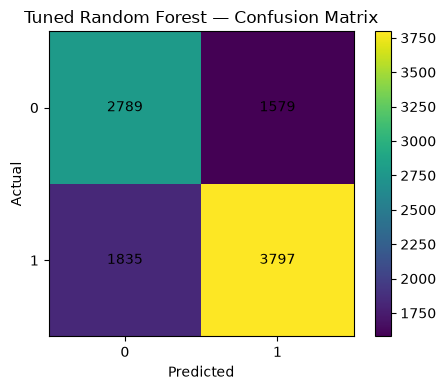

In [11]:
# ============================================================
# 11. Confusion matrix
# ============================================================

cm = confusion_matrix(yte, tuned_predictions)

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(cm)

ax.set_title("Tuned Random Forest — Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

for row in range(2):
    for column in range(2):
        ax.text(
            column,
            row,
            cm[row, column],
            ha="center",
            va="center",
        )

plt.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()


In [12]:
# ============================================================
# 12. Classification probability threshold analysis
# ============================================================

threshold_rows = []

for threshold in np.arange(0.20, 0.81, 0.05):

    threshold_predictions = (
        tuned_probabilities >= threshold
    ).astype(int)

    threshold_rows.append({
        "Threshold": round(float(threshold), 2),
        "Precision": precision_score(
            yte,
            threshold_predictions,
            zero_division=0,
        ),
        "Recall": recall_score(
            yte,
            threshold_predictions,
            zero_division=0,
        ),
        "F1": f1_score(
            yte,
            threshold_predictions,
            zero_division=0,
        ),
    })

threshold_df = pd.DataFrame(threshold_rows)

display(threshold_df)

best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(
    "Best threshold by holdout F1:",
    best_threshold_row.to_dict()
)


,Threshold,Precision,Recall,F1
0,0.20,0.585325,0.987216,0.734915
1,0.25,0.598269,0.969638,0.739973
2,0.30,0.612739,0.939453,0.741712
3,0.35,0.631822,0.900391,0.742568
4,0.40,0.656319,0.848366,0.740087
5,0.45,0.680519,0.773438,0.724009
6,0.50,0.706287,0.674183,0.689862
7,0.55,0.735267,0.571555,0.643157
8,0.60,0.768709,0.483310,0.593481
9,0.65,0.785714,0.394531,0.525296


Best threshold by holdout F1: {'Threshold': 0.35, 'Precision': 0.6318215798654373, 'Recall': 0.900390625, 'F1': 0.7425684580465661}


# Part B — Regression: Delivery Time Prediction

The regression model estimates `actual_delivery_days` using information that can reasonably be available before final delivery.

Leakage-prone outcome columns remain excluded.


In [13]:
# ============================================================
# 13. Regression dataset and split
# ============================================================

regression_mask = (
    data["actual_delivery_days_target"].notna()
    & (data["actual_delivery_days_target"] >= 0)
)

X_reg = X_all.loc[regression_mask].copy()
y_reg = data.loc[
    regression_mask,
    "actual_delivery_days_target"
].astype(float)

if len(X_reg) == 0:
    raise ValueError(
        "No usable regression rows remain after target cleaning."
    )

Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print("Regression rows:", len(X_reg))
print("Training rows:", len(Xtr_r))
print("Testing rows:", len(Xte_r))

print("\nTarget summary:")
print(y_reg.describe())


Regression rows: 50000
Training rows: 40000
Testing rows: 10000

Target summary:
count    50000.000000
mean         8.345940
std          4.644353
min          0.000000
25%          5.000000
50%          8.000000
75%         12.000000
max         27.000000
Name: actual_delivery_days_target, dtype: float64


In [14]:
# ============================================================
# 14. Regression model comparison
# ============================================================

regression_models = {
    "Ridge Regression": Ridge(alpha=1.0),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=15,
        random_state=RANDOM_STATE,
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=150,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "HistGradient Boosting": HistGradientBoostingRegressor(
        max_iter=150,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE,
    ),
}

regression_results = []
regression_pipelines = {}

for model_name, model in regression_models.items():

    print(f"Training: {model_name}")

    pipeline = Pipeline([
        ("preprocessor", build_preprocessor(Xtr_r)),
        ("model", model),
    ])

    pipeline.fit(Xtr_r, ytr_r)

    predictions = pipeline.predict(Xte_r)

    regression_results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(yte_r, predictions),
        "RMSE": np.sqrt(
            mean_squared_error(yte_r, predictions)
        ),
        "R2": r2_score(yte_r, predictions),
    })

    regression_pipelines[model_name] = pipeline

regression_results_df = (
    pd.DataFrame(regression_results)
    .sort_values("RMSE", ascending=True)
    .reset_index(drop=True)
)

display(regression_results_df)


Training: Ridge Regression
Training: Decision Tree
Training: Random Forest
Training: Extra Trees
Training: HistGradient Boosting


,Model,MAE,RMSE,R2
0,HistGradient Boosting,1.171437,1.631039,0.876003
1,Ridge Regression,1.178827,1.638588,0.874852
2,Random Forest,1.184623,1.662245,0.871213
3,Extra Trees,1.253781,1.770851,0.853834
4,Decision Tree,1.303684,1.885716,0.834257


In [16]:
# ============================================================
# 15. Regression 5-fold cross-validation — FAST VERSION
# ============================================================

regression_cv = KFold(
    n_splits=3,   # Reduced from 5 for faster execution
    shuffle=True,
    random_state=RANDOM_STATE,
)

regression_cv_rows = []

# Use a representative sample for CV to keep notebook execution practical
CV_SAMPLE_SIZE = min(15000, len(X_reg))

X_reg_cv = X_reg.sample(
    n=CV_SAMPLE_SIZE,
    random_state=RANDOM_STATE
)

y_reg_cv = y_reg.loc[X_reg_cv.index]

print(f"Running 3-fold CV on {len(X_reg_cv):,} samples...")

for model_name, model in regression_models.items():

    print(f"Testing: {model_name}")

    pipeline = Pipeline([
        ("preprocessor", build_preprocessor(X_reg_cv)),
        ("model", model),
    ])

    negative_rmse = cross_val_score(
        pipeline,
        X_reg_cv,
        y_reg_cv,
        cv=regression_cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )

    rmse_scores = -negative_rmse

    regression_cv_rows.append({
        "Model": model_name,
        "CV_RMSE_Mean": rmse_scores.mean(),
        "CV_RMSE_STD": rmse_scores.std(),
    })

regression_cv_df = (
    pd.DataFrame(regression_cv_rows)
    .sort_values("CV_RMSE_Mean", ascending=True)
    .reset_index(drop=True)
)

display(regression_cv_df)

Running 3-fold CV on 15,000 samples...
Testing: Ridge Regression
Testing: Decision Tree
Testing: Random Forest
Testing: Extra Trees
Testing: HistGradient Boosting


,Model,CV_RMSE_Mean,CV_RMSE_STD
0,Ridge Regression,1.666575,0.017853
1,HistGradient Boosting,1.691686,0.015844
2,Random Forest,1.703445,0.016143
3,Extra Trees,1.813174,0.027523
4,Decision Tree,2.017648,0.020999


Top 20 classification features:


,Feature,Importance
0,numeric__distance_km,0.122010
1,numeric__shipping_cost_usd,0.099683
2,numeric__promised_delivery_days,0.072159
3,numeric__order_value_usd,0.060040
4,numeric__product_weight_kg,0.053193
5,numeric__order_day,0.049290
6,numeric__order_month,0.039047
7,numeric__order_dayofweek,0.031304
8,categorical__shipping_method_Express,0.014147
9,categorical__shipping_method_International,0.013157


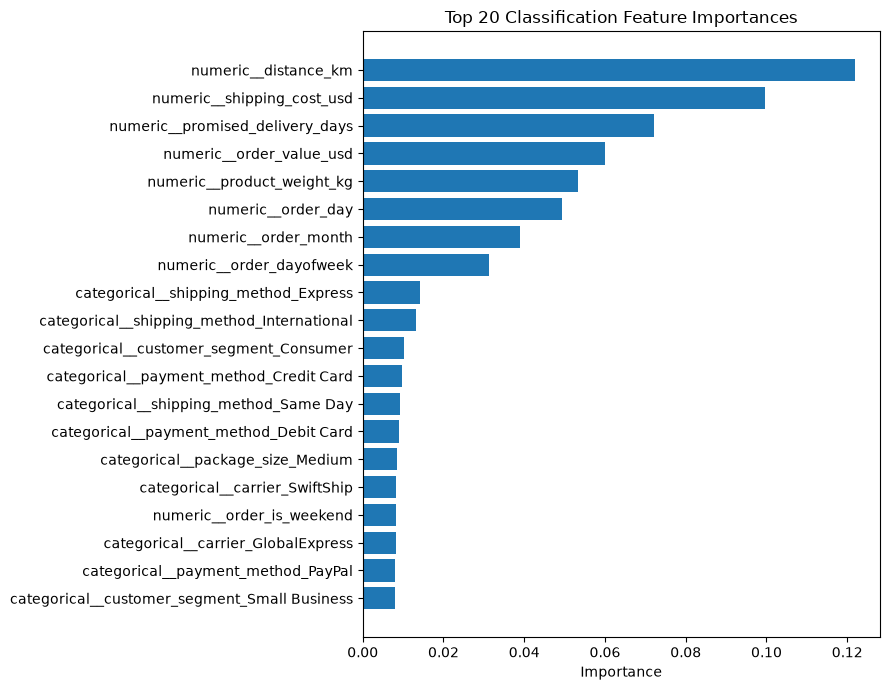

In [17]:
# ============================================================
# 16. Classification feature importance
# ============================================================

fitted_preprocessor = best_rf_model.named_steps["preprocessor"]
fitted_rf = best_rf_model.named_steps["model"]

try:
    transformed_feature_names = (
        fitted_preprocessor.get_feature_names_out()
    )

    importance_df = pd.DataFrame({
        "Feature": transformed_feature_names,
        "Importance": fitted_rf.feature_importances_,
    }).sort_values(
        "Importance",
        ascending=False,
    ).reset_index(drop=True)

    print("Top 20 classification features:")
    display(importance_df.head(20))

    top_features = importance_df.head(20).sort_values(
        "Importance"
    )

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(
        top_features["Feature"],
        top_features["Importance"],
    )
    ax.set_title("Top 20 Classification Feature Importances")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

except Exception as error:
    print("Feature importance could not be generated:", error)


In [18]:
# ============================================================
# 17. Save deployment-ready models
# ============================================================

classification_model_path = (
    MODEL_DIR / "late_delivery_risk_model.joblib"
)

joblib.dump(
    best_rf_model,
    classification_model_path,
)

# Select best regression model using lowest holdout RMSE.
best_regression_name = regression_results_df.iloc[0]["Model"]
best_regression_model = regression_pipelines[
    best_regression_name
]

regression_model_path = (
    MODEL_DIR / "delivery_time_model.joblib"
)

joblib.dump(
    best_regression_model,
    regression_model_path,
)

metadata = {
    "random_state": RANDOM_STATE,
    "classification_target": "late_delivery_target",
    "classification_source_column": "late_delivery",
    "regression_target": "actual_delivery_days_target",
    "regression_source_column": "actual_delivery_days",
    "features": feature_columns,
    "leakage_columns": sorted(leakage_columns),
    "classification_model": "Tuned Random Forest",
    "classification_metrics": tuned_classification_metrics,
    "classification_threshold": float(
        best_threshold_row["Threshold"]
    ),
    "random_search_best_cv_f1": float(
        random_search.best_score_
    ),
    "random_search_best_params": random_search.best_params_,
    "regression_model": best_regression_name,
    "regression_holdout_metrics": regression_results_df.iloc[
        0
    ].to_dict(),
}

metadata_path = MODEL_DIR / "model_metadata.json"

with open(
    metadata_path,
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        metadata,
        metadata_file,
        indent=2,
        default=float,
    )

print("Saved classification model:")
print(classification_model_path)

print("\nSaved regression model:")
print(regression_model_path)

print("\nSaved metadata:")
print(metadata_path)


Saved classification model:
c:\Users\bagad\OneDrive\Desktop\LogiSense\LogiSense\models\late_delivery_risk_model.joblib

Saved regression model:
c:\Users\bagad\OneDrive\Desktop\LogiSense\LogiSense\models\delivery_time_model.joblib

Saved metadata:
c:\Users\bagad\OneDrive\Desktop\LogiSense\LogiSense\models\model_metadata.json


In [19]:
# ============================================================
# 18. Final model sanity checks
# ============================================================

loaded_classification_model = joblib.load(
    classification_model_path
)

loaded_regression_model = joblib.load(
    regression_model_path
)

print("Classification sample probabilities:")
print(
    loaded_classification_model
    .predict_proba(Xte.head(5))[:, 1]
)

print("\nRegression sample predictions:")
print(
    loaded_regression_model.predict(
        Xte_r.head(5)
    )
)

print("\nFinal classification comparison:")
display(classification_results_df)

print("\nFinal regression comparison:")
display(regression_results_df)

print("\n" + "=" * 60)
print("NOTEBOOK 04 COMPLETED SUCCESSFULLY")
print("=" * 60)


Classification sample probabilities:
[0.56091663 0.5875435  0.53273417 0.74717521 0.49561877]

Regression sample predictions:
[ 6.7520806  10.04355794  2.29367326  2.24640065  5.49048145]

Final classification comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,HistGradient Boosting,0.6748,0.687166,0.775746,0.728774,0.727147
1,Extra Trees,0.6575,0.674964,0.755859,0.713125,0.698104
2,Random Forest,0.6564,0.700658,0.680753,0.690562,0.714544
3,Decision Tree,0.6436,0.699076,0.644709,0.670793,0.684717
4,Logistic Regression,0.6442,0.713903,0.614524,0.660496,0.707858



Final regression comparison:


,Model,MAE,RMSE,R2
0,HistGradient Boosting,1.171437,1.631039,0.876003
1,Ridge Regression,1.178827,1.638588,0.874852
2,Random Forest,1.184623,1.662245,0.871213
3,Extra Trees,1.253781,1.770851,0.853834
4,Decision Tree,1.303684,1.885716,0.834257



NOTEBOOK 04 COMPLETED SUCCESSFULLY
